In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from shared.rlhc import random_latin_hypercube

# 2 Constructing a Surrogate

## 2.3 Radial Basis Function Models

$$f(x) = \bm{w}^T \bm{\psi} = \sum_{i=1}^{n_c}w_i\psi(\left\lVert x-c^{(i)} \right\rVert)$$

In [2]:
def peaks(x, y):
    return (3 * (1 - x)**2 * np.exp(-x**2 - (y + 1)**2)
            - 10 * (x/5 - x**3 - y**5) * np.exp(-x**2 - y**2)
            - 1/3 * np.exp(-(x + 1)**2 - y**2))

In [ ]:
def psi(r: np.ndarray, code: int = 1, sigma: float = None):
    
    match code:
        case 1: # linear
            return r
        case 2: # cubic
            return r**3 
        case 3: # thin plate spline
            return (r**2) * np.log(r) 
        case 4: # Gaussian
            return np.exp(-(r**2)/(2*(sigma**2)))
        case 5: # multi-quadratic
            return np.sqrt(r**2 + sigma**2)
        case 6: # inverse multi-quadratic
            return 1 / (np.sqrt(r**2 + sigma**2))


def psi_gram_matrix(X: np.ndarray) -> np.ndarray:
    # original approach
    # n = X.shape[0]
    # k = X.shape[1]
    # PSI = np.zeros((n,n))

    # for i in range(n):
    #     for j in range(n):
    #         dist = np.linalg.norm(X[i] - X[j])
    #         PSI[i,j] = psi(dist,1)
    # return PSI

    # claude suggestion
    D = cdist(X, X)
    return psi(D, 1)

# get our sample
X        = random_latin_hypercube(20,2,-3,3)

# solve for weights
PSI      = psi_gram_matrix(X)
y_sample = peaks(X[:,0],X[:,1])
w        = np.linalg.solve(PSI, y_sample)

x1 = np.linspace(-3, 3, 200)
x2 = np.linspace(-3, 3, 200)

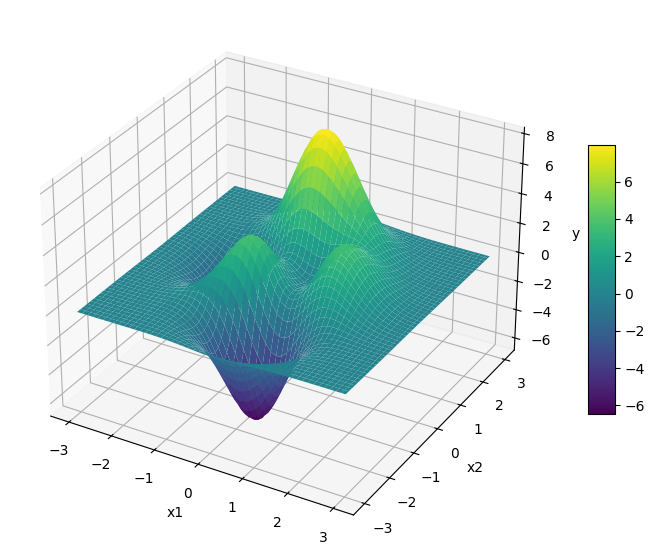

In [12]:
x1 = np.linspace(-3, 3, 200)
x2 = np.linspace(-3, 3, 200)
X1, X2 = np.meshgrid(x1, x2)
Y = peaks(X1, X2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X1, X2, Y, cmap='viridis', linewidth=0, antialiased=True)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
fig.colorbar(surf, shrink=0.5, aspect=10)

plt.show()